In [ ]:
import numpy as np
import pandas as pd

# ------------------------------------------
# 1. Read Student Details Dataset

df1 = pd.read_csv(r"/content/Student_Details_Dataset_100rows_with_nulls_updated.csv")
print("Student Details Dataset:")
print(df1)

# ------------------------------------------
# 2. Read Events Participation Dataset

df2 = pd.read_csv(r"/content/Events_Participation_Dataset_100rows.csv")
print("\nEvents Participation Dataset:")
print(df2)

# ---------------------------------------------
# 3. Cleaning NaN Values in "Year" Column

before_cleaning = df1['Year']
print("\nYear Column Before Cleaning:")
print(before_cleaning)

after_cleaning = df1['Year'].dropna()
print("\nYear Column After Cleaning (NaN Removed):")
print(after_cleaning)

# ---------------------------------------------
# 4. Merge Both Datasets using StudentID

merged_df = pd.merge(df1, df2, on='StudentID', how='inner')

print("\nMerged Dataset (Full Rows):")
print(merged_df)

# ---------------------------------------------
# 5. Add Performance Column (Winner = Excellent, Participant = Average)

def performance_category(row):
    if row['ParticipationType'] == "Winner":
        return "Excellent"
    else:
        return "Average"

merged_df['Performance'] = merged_df.apply(performance_category, axis=1)

# ---------------------------------------------
# 6. Display Entire Student Row with Performance Condition

print("\nFinal Student Rows with Performance Column Applied:\n")
print(merged_df[['StudentID', 'StudentName', 'Year',
                 'EventName', 'ParticipationType', 'Performance']])

# ---------------------------------------------
# 7. Rank Mapping Based on Performance

rank_map = {
    "Excellent": 1,
    "Average": 2
}

merged_df['Rank'] = merged_df['Performance'].map(rank_map)

# ---------------------------------------------
# 8. Sort Dataset by Rank

merged_df = merged_df.sort_values('Rank')

print("\nFinal Sorted Dataset with Full Student Rows:\n")
print(merged_df)

# ---------------------------------------------
# 9. Save Final Output CSV

merged_df.to_csv("final_student_performance.csv", index=False)

print("\nFinal Student Performance File Saved as: final_student_performance.csv")


Student Details Dataset:
   StudentID StudentName  Department  Year                   Email
0       S101    Student1         ECE   NaN    student1@college.com
1       S102    Student2          IT   3.0    student2@college.com
2       S103    Student3  Mechanical   4.0    student3@college.com
3       S104    Student4       Civil   1.0    student4@college.com
4       S105    Student5         CSE   2.0    student5@college.com
..       ...         ...         ...   ...                     ...
95      S196   Student96         ECE   1.0   student96@college.com
96      S197   Student97          IT   2.0   student97@college.com
97      S198   Student98  Mechanical   3.0   student98@college.com
98      S199   Student99       Civil   4.0   student99@college.com
99      S200  Student100         CSE   1.0  student100@college.com

[100 rows x 5 columns]

Events Participation Dataset:
   StudentID       EventName ParticipationType CertificatesWon EventCategory
0       S101   Cultural Fest         Or

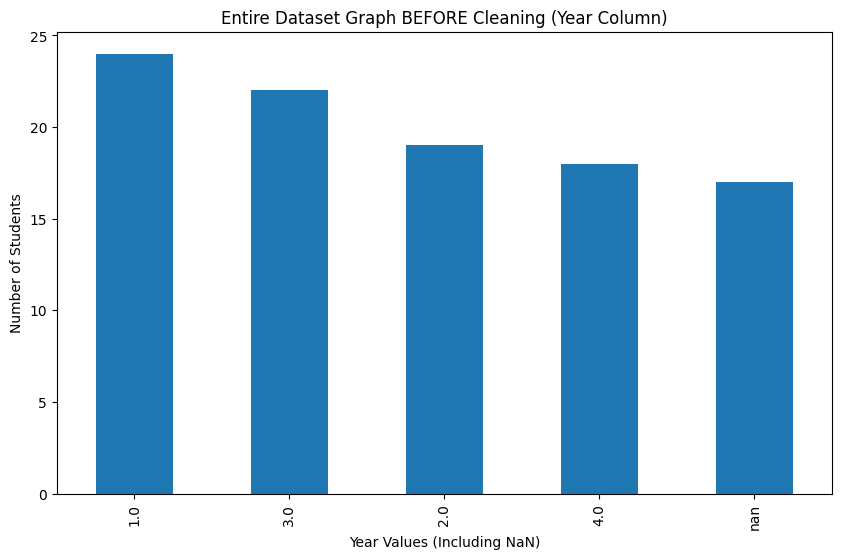

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# Load Dataset (Before Cleaning)
df = pd.read_csv(r"/content/Student_Details_Dataset_100rows_with_nulls_updated.csv")

# Plot Entire Dataset Year Distribution (Including NaN)
plt.figure(figsize=(10,6))

df['Year'].value_counts(dropna=False).plot(kind='bar')

plt.title("Entire Dataset Graph BEFORE Cleaning (Year Column)")
plt.xlabel("Year Values (Including NaN)")
plt.ylabel("Number of Students")

plt.show()


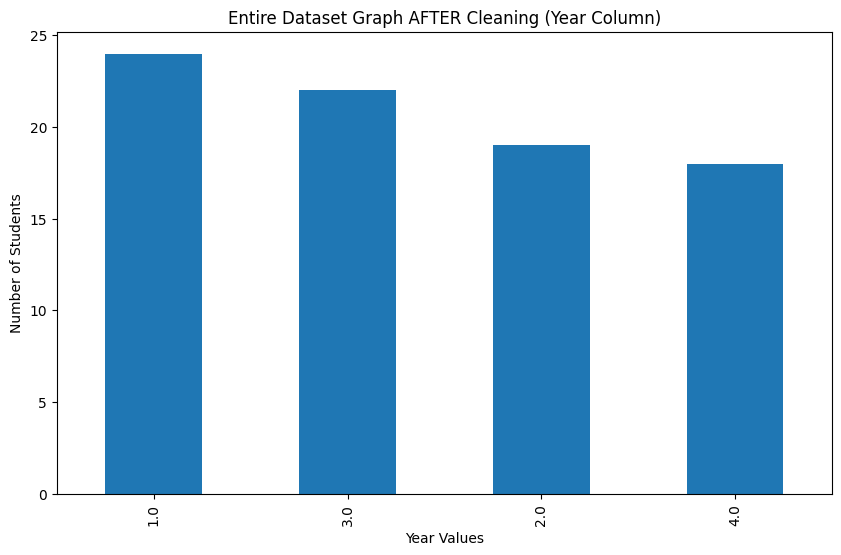

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# Load Dataset
df = pd.read_csv(r"/content/Student_Details_Dataset_100rows_with_nulls_updated.csv")

# Cleaning: Remove NaN Values from Year Column
df_cleaned = df.dropna(subset=['Year'])

# Plot Entire Dataset Year Distribution (After Cleaning)
plt.figure(figsize=(10,6))

df_cleaned['Year'].value_counts().plot(kind='bar')

plt.title("Entire Dataset Graph AFTER Cleaning (Year Column)")
plt.xlabel("Year Values")
plt.ylabel("Number of Students")

plt.show()


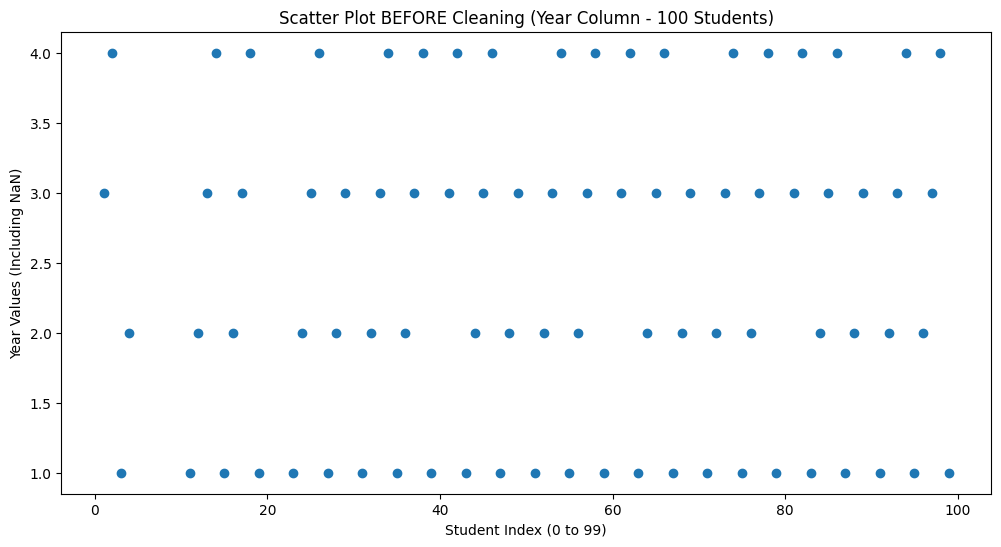

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# Load Dataset (Before Cleaning)
df = pd.read_csv(r"/content/Student_Details_Dataset_100rows_with_nulls_updated.csv")

# Scatter Plot Before Cleaning
plt.figure(figsize=(12,6))

plt.scatter(df.index, df['Year'])

plt.title("Scatter Plot BEFORE Cleaning (Year Column - 100 Students)")
plt.xlabel("Student Index (0 to 99)")
plt.ylabel("Year Values (Including NaN)")

plt.show()


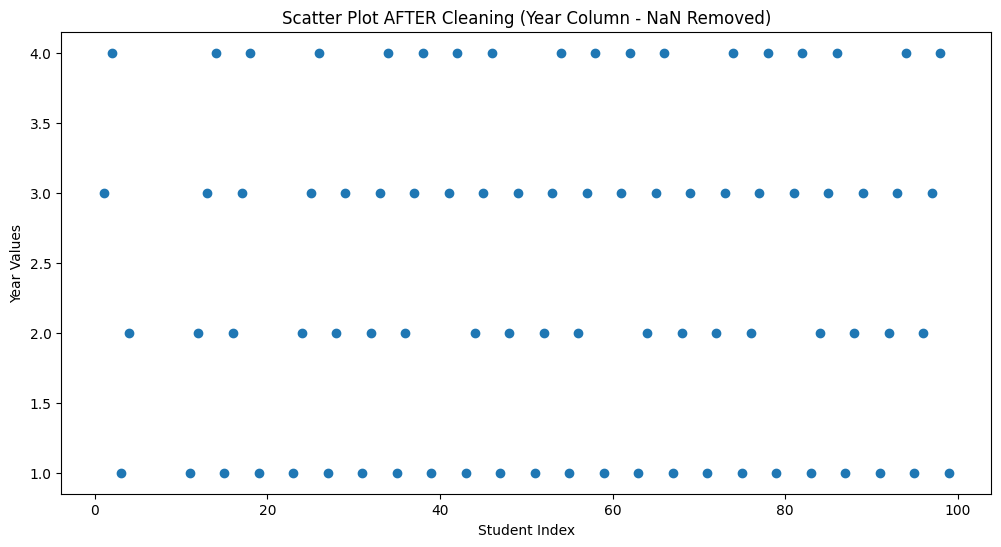

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# Load Dataset
df = pd.read_csv(r"/content/Student_Details_Dataset_100rows_with_nulls_updated.csv")

# Remove NaN Values (Cleaning)
df_cleaned = df.dropna(subset=['Year'])

# Scatter Plot After Cleaning
plt.figure(figsize=(12,6))

plt.scatter(df_cleaned.index, df_cleaned['Year'])

plt.title("Scatter Plot AFTER Cleaning (Year Column - NaN Removed)")
plt.xlabel("Student Index")
plt.ylabel("Year Values")

plt.show()


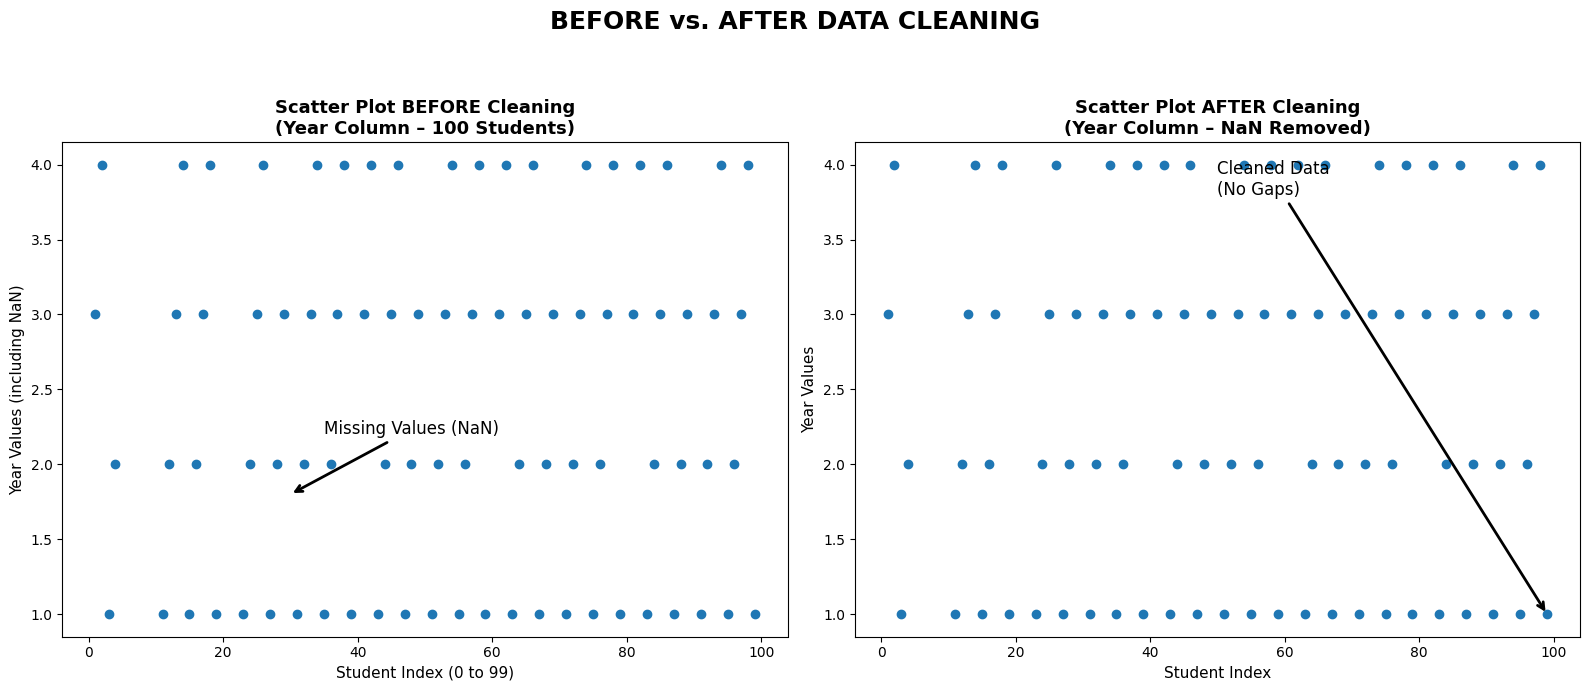

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# -------------------------------
# Load Dataset
df1 = pd.read_csv(r"/content/Student_Details_Dataset_100rows_with_nulls_updated.csv")

# -------------------------------
# Year Column BEFORE Cleaning
before_cleaning = df1['Year']

# Year Column AFTER Cleaning (Remove NaN)
after_cleaning = df1.dropna(subset=['Year'])

# -------------------------------
# Create Split Scatter Plot Figure
plt.figure(figsize=(16,7))

# =====================================================
# LEFT SIDE: BEFORE CLEANING
plt.subplot(1, 2, 1)

plt.scatter(df1.index, before_cleaning)

plt.title("Scatter Plot BEFORE Cleaning\n(Year Column – 100 Students)",
          fontsize=13, fontweight="bold")

plt.xlabel("Student Index (0 to 99)", fontsize=11)
plt.ylabel("Year Values (including NaN)", fontsize=11)

# Annotation for Missing Values
plt.annotate("Missing Values (NaN)",
             xy=(30, 1.8), xytext=(35, 2.2),
             arrowprops=dict(arrowstyle="->", lw=2),
             fontsize=12)

# =====================================================
# RIGHT SIDE: AFTER CLEANING
plt.subplot(1, 2, 2)

plt.scatter(after_cleaning.index, after_cleaning['Year'])

plt.title("Scatter Plot AFTER Cleaning\n(Year Column – NaN Removed)",
          fontsize=13, fontweight="bold")

plt.xlabel("Student Index", fontsize=11)
plt.ylabel("Year Values", fontsize=11)

# Annotation for Cleaned Data
plt.annotate("Cleaned Data\n(No Gaps)",
             xy=(after_cleaning.index[-1], after_cleaning['Year'].iloc[-1]),
             xytext=(50, 3.8),
             arrowprops=dict(arrowstyle="->", lw=2),
             fontsize=12)

# =====================================================
# MAIN TITLE (Like Image Heading)
plt.suptitle("BEFORE vs. AFTER DATA CLEANING",
             fontsize=18, fontweight="bold")

# Adjust Layout
plt.tight_layout(rect=[0, 0, 1, 0.93])

plt.show()
